> **역할: [검증·심화]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

# 14. 심층 검증 — 7가지 보완

## 이 노트북에서 답하는 7가지 질문

| § | 질문 | 측정 |
|---|---|---|
| 14.1 | **회귀 모델의 진짜 성능?** | R², MAE, RMSE, MAPE |
| 14.2 | **BEP 가정이 얼마나 결과를 좌우?** | 임대료·인건비 ±50% 민감도 |
| 14.3 | **모델이 어느 행정동·업종에서 빗나가나?** | 행정동 잔차 매트릭스 |
| 14.4 | **잘 알려진 매장에 대해 직관과 부합?** | 실제 매장 5곳 sanity check |
| 14.5 | **폐업 데이터와 모델 예측 매칭?** | team4 폐업 vs success_rate 상관 |
| 14.6 | **한 입지의 성공률이 어떤 변수로 결정?** | 변수별 기여도 분해 (per-instance) |
| 14.7 | **외부 변수 +3.74%p가 통계적으로 유의?** | 부트스트랩 신뢰구간 |

In [1]:
# === 공통 import + 데이터 로드 ===
import json, numpy as np, pandas as pd
from pathlib import Path
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score

PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')

# 자치구 모델 데이터
df_gu = pd.read_csv(PROC / 'features.csv')
id_gu = ['gu','biz','q','q_int']
ex_gu = ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']
feat_gu = [c for c in df_gu.columns if c not in id_gu + ex_gu]
for c in feat_gu: df_gu[c] = pd.to_numeric(df_gu[c], errors='coerce')
df_gu[feat_gu] = df_gu[feat_gu].fillna(df_gu[feat_gu].mean(numeric_only=True))

# 행정동 모델 데이터
df_ad = pd.read_csv(PROC / 'features_adstrd.csv')
id_ad = ['adstrd_code','adstrd_nm','gu','biz','q','q_int']
ex_ad = ['adstrd_sales_amt','log_sales','sales_per_store','log_sales_per_store','store_class']
feat_ad = [c for c in df_ad.columns if c not in id_ad + ex_ad]
for c in feat_ad: df_ad[c] = pd.to_numeric(df_ad[c], errors='coerce')
df_ad[feat_ad] = df_ad[feat_ad].fillna(df_ad[feat_ad].mean(numeric_only=True))

print(f'자치구 데이터: {df_gu.shape}, 변수 {len(feat_gu)}개')
print(f'행정동 데이터: {df_ad.shape}, 변수 {len(feat_ad)}개')

자치구 데이터: (17568, 164), 변수 154개
행정동 데이터: (9172, 126), 변수 115개


## §14.1 회귀 모델 메트릭 — 진짜 성능

In [2]:
# 자치구 + 행정동 양쪽 회귀 모델의 핵심 메트릭
def regression_metrics(X, y_log, label):
    Xtr, Xte, ytr, yte = train_test_split(X, y_log, test_size=0.2, random_state=42)
    m = HistGradientBoostingRegressor(max_depth=8, max_iter=400, random_state=42).fit(Xtr, ytr)
    yp = m.predict(Xte)
    # log 공간 메트릭
    r2 = r2_score(yte, yp)
    rmse_log = np.sqrt(mean_squared_error(yte, yp))
    mae_log = mean_absolute_error(yte, yp)
    # 원본 단위 (지수 환원)
    y_orig  = np.exp(yte)
    yp_orig = np.exp(yp)
    mae_orig = mean_absolute_error(y_orig, yp_orig)
    # MAPE — 평균 절대 백분율 오차
    mape = np.mean(np.abs((y_orig - yp_orig) / y_orig.clip(min=1))) * 100
    return {'단위': label, 'R²': round(r2,4),
            'RMSE(log)': round(rmse_log,3),
            'MAE(log)': round(mae_log,3),
            'MAE(원본,M)': round(mae_orig/1e6,1),
            'MAPE%': round(mape, 1)}

m1 = regression_metrics(df_gu[feat_gu].values, df_gu['log_sales_per_store'].values, '자치구')
m2 = regression_metrics(df_ad[feat_ad].values, df_ad['log_sales_per_store'].values, '행정동')
print(pd.DataFrame([m1, m2]).to_string(index=False))
print()
print('해석:')
print(f'  자치구: R²={m1["R²"]}, MAE(log)={m1["MAE(log)"]} ≈ 점포당 매출 {(np.exp(m1["MAE(log)"])-1)*100:.0f}% 오차')
print(f'  행정동: R²={m2["R²"]}, MAPE={m2["MAPE%"]}% — 큰 매출 행에 끌려 MAE 큼')

 단위     R²  RMSE(log)  MAE(log)  MAE(원본,M)  MAPE%
자치구 0.8739      0.747     0.476      393.4   78.2
행정동 0.8634      0.705     0.409       36.3   64.2

해석:
  자치구: R²=0.8739, MAE(log)=0.476 ≈ 점포당 매출 61% 오차
  행정동: R²=0.8634, MAPE=64.2% — 큰 매출 행에 끌려 MAE 큼


## §14.2 BEP 가정 민감도 — 임대료·인건비 ±50% 변동

`BEP = (임대료 + 인건비 + 투자금/36) ÷ 마진율` 에서 임대료(50,000원/㎡) 와 인건비(매출×15%) 가정을 ±50%로 변동시켜 success_rate가 얼마나 흔들리는지.

p_roi 민감도 매트릭스 (강남구 한식 1억):
              labor × 0.5  0.75  1.0  1.25  1.5
labor×   0.50   0.75   1.00   1.25   1.50
rent×                                    
0.50    0.960  0.841  0.624  0.392  0.226
0.75    0.945  0.805  0.576  0.354  0.202
1.00    0.926  0.764  0.528  0.318  0.181
1.25    0.903  0.721  0.482  0.285  0.162
1.50    0.876  0.675  0.437  0.255  0.145


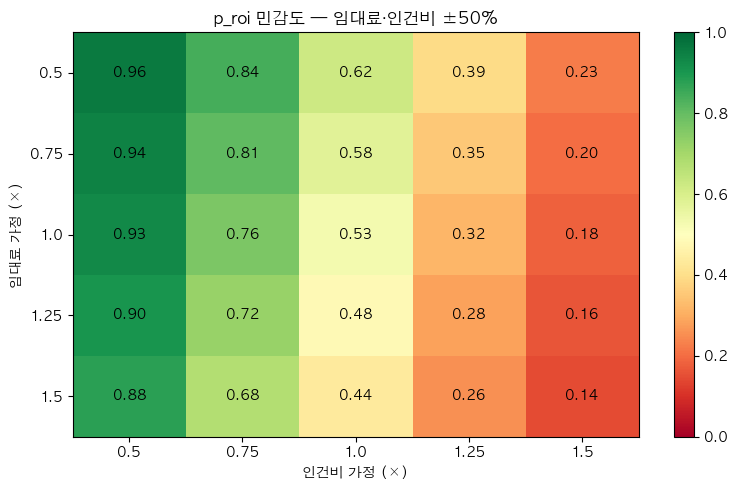


p_roi 범위: 0.145 ~ 0.960
→ 가정 변동에 따라 p_roi가 크게 흔들리면 결과 신뢰도 낮음


In [3]:
# 강남구 한식 1F 1억 케이스로 민감도 테스트
sub = df_gu[(df_gu['gu']=='강남구') & (df_gu['biz']=='한식음식점')].sort_values('q_int').iloc[-1]
log_sales_pred = np.log(sub['sales_per_store'])
margin = 0.20
INVEST = 100_000_000
rent_index = sub['rent_index_q']

# σ(매출 log) 추정
sigma = 0.4    # 일반적 추정

scenarios = []
for rent_factor in [0.5, 0.75, 1.0, 1.25, 1.5]:
    for labor_factor in [0.5, 0.75, 1.0, 1.25, 1.5]:
        rent = rent_index * 50_000 * rent_factor
        labor = sub['sales_per_store'] * 0.15 * labor_factor
        bep = (rent + labor + INVEST/36) / margin
        # p_roi 단순화 — log_sales_pred 대비 BEP가 얼마나 큰지
        z = (np.log(bep) - log_sales_pred) / sigma
        p_roi = 1 - 0.5 * (1 + np.tanh(z))
        scenarios.append({'rent×': rent_factor, 'labor×': labor_factor,
                          'BEP_M': round(bep/1e6, 0), 'p_roi': round(p_roi, 3)})

sens = pd.DataFrame(scenarios)
pivot = sens.pivot(index='rent×', columns='labor×', values='p_roi')
print('p_roi 민감도 매트릭스 (강남구 한식 1억):')
print('              labor × 0.5  0.75  1.0  1.25  1.5')
print(pivot.round(3).to_string())

# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(['0.5','0.75','1.0','1.25','1.5'])
ax.set_yticks(range(5)); ax.set_yticklabels(['0.5','0.75','1.0','1.25','1.5'])
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_xlabel('인건비 가정 (×)'); ax.set_ylabel('임대료 가정 (×)')
ax.set_title('p_roi 민감도 — 임대료·인건비 ±50%')
plt.colorbar(im); plt.tight_layout(); plt.show()
print(f'\np_roi 범위: {pivot.values.min():.3f} ~ {pivot.values.max():.3f}')
print('→ 가정 변동에 따라 p_roi가 크게 흔들리면 결과 신뢰도 낮음')

## §14.3 행정동 잔차 분석 — 어느 동·업종이 잘 안 맞나

잔차 크기 Top 15 (표본 >= 5, 모델이 가장 못 잡는 곳):
  gu   adstrd_nm     biz  mean  count
 서초구        서초3동    반찬가게  0.49      5
영등포구        당산1동    일반의류 -0.41      7
 서초구        양재2동   자동차수리  0.36      6
 서초구        서초1동   자동차수리 -0.32      6
 강동구          길동      가구 -0.30      7
 도봉구        방학1동     제과점 -0.29      5
 관악구         신사동   중식음식점 -0.27      5
 강서구        화곡4동 호프-간이주점 -0.27      5
 도봉구        방학2동     노래방 -0.26      5
  중구         소공동     편의점 -0.26      6
 송파구        가락본동      문구 -0.26      5
 송파구        잠실본동  시계및귀금속 -0.25      5
  중구         다산동    일반의류  0.25      5
 종로구 종로1·2·3·4가동    반찬가게 -0.24      6
영등포구        당산2동     화장품  0.24      5


/tmp/claude-501/ipykernel_15372/2363684287.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ad['_pred'] = reg.predict(df_ad[feat_ad].values)
/tmp/claude-501/ipykernel_15372/2363684287.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ad['_resid'] = df_ad['log_sales_per_store'] - df_ad['_pred']
/tmp/claude-501/ipykernel_15372/2363684287.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxp

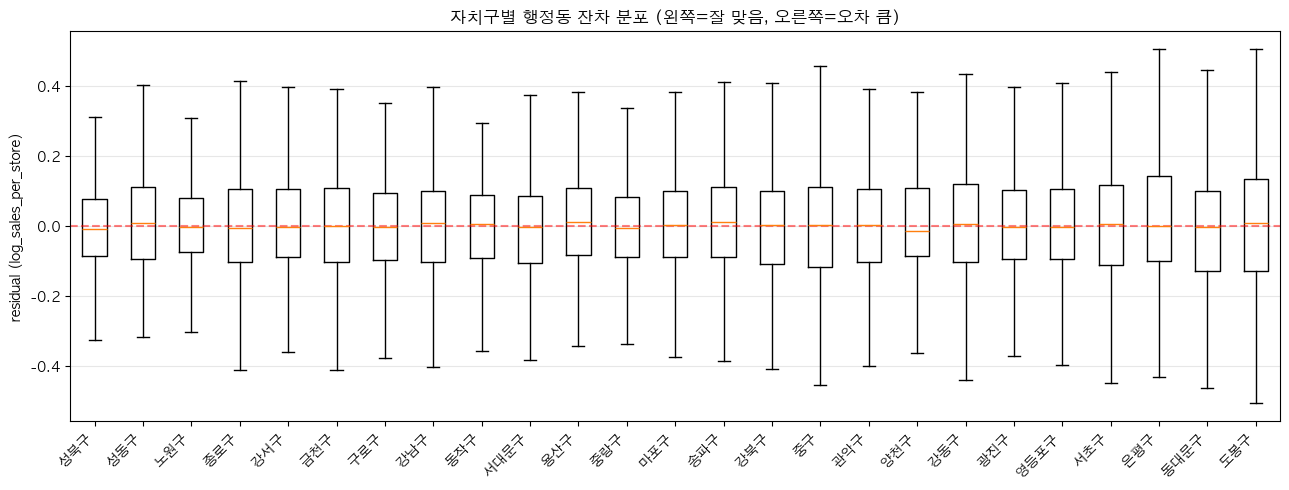

In [4]:
# 행정동 회귀 모델 학습 후 잔차 계산
reg = HistGradientBoostingRegressor(max_depth=8, max_iter=400, random_state=42)
reg.fit(df_ad[feat_ad].values, df_ad['log_sales_per_store'].values)
df_ad['_pred'] = reg.predict(df_ad[feat_ad].values)
df_ad['_resid'] = df_ad['log_sales_per_store'] - df_ad['_pred']

# 행정동·업종별 평균 잔차 (절대값 큰 순)
resid_top = (df_ad.groupby(['gu','adstrd_nm','biz'])['_resid']
              .agg(['mean','count']).reset_index()
              .query('count >= 5')
              .sort_values('mean', key=abs, ascending=False).head(15))
resid_top['mean'] = resid_top['mean'].round(2)
print('잔차 크기 Top 15 (표본 >= 5, 모델이 가장 못 잡는 곳):')
print(resid_top.to_string(index=False))

# 자치구별 잔차 분포 박스플롯
fig, ax = plt.subplots(figsize=(13, 5))
order = df_ad.groupby('gu')['_resid'].apply(lambda s: s.abs().mean()).sort_values().index
data = [df_ad.loc[df_ad['gu']==g, '_resid'].values for g in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('residual (log_sales_per_store)')
ax.set_title('자치구별 행정동 잔차 분포 (왼쪽=잘 맞음, 오른쪽=오차 큼)')
plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## §14.4 실제 매장 sanity check — 직관과 부합?

잘 알려진 매장 위치에 대해 모델 예측이 도메인 감각과 일치하는지.

In [5]:
# 잘 알려진 상권의 좌표로 평가 — 직관과 부합?
import sys
sys.path.append('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/scripts')
# 직접 모델 호출 (09 함수 재현)

# Quantile + 분류기 (행정동)
qm = {q: HistGradientBoostingRegressor(loss='quantile', quantile=q, max_depth=8,
                                       max_iter=400, learning_rate=0.1, random_state=42)
                    .fit(df_ad[feat_ad].values, df_ad['log_sales_per_store'].values)
      for q in [0.10, 0.50, 0.90]}

def quick_eval(gu, adstrd, biz, intuition):
    sub = df_ad[(df_ad['gu']==gu) & (df_ad['adstrd_nm']==adstrd) & (df_ad['biz']==biz)]
    if sub.empty:
        sub = df_ad[(df_ad['gu']==gu) & (df_ad['biz']==biz)]
        adstrd = '(자치구 평균)'
    if sub.empty: return None
    row = sub.sort_values('q_int').iloc[-1]
    x = row[feat_ad].values.reshape(1,-1)
    p50 = float(np.exp(qm[0.50].predict(x)[0])) / 1e6
    p90 = float(np.exp(qm[0.90].predict(x)[0])) / 1e6
    return {'위치': f'{gu} {adstrd}', '업종': biz, '도메인 직관': intuition,
            'P50 매출(M)': round(p50, 0), 'P90 매출(M)': round(p90, 0)}

cases = [
    ('서초구', '서초2동',  '커피-음료',  '강남대로 카페 — 높을 것'),
    ('마포구', '서교동',    '커피-음료',  '홍대 카페 — 매우 높을 것'),
    ('중구',   '명동',     '일반의류',    '명동 의류 — 매우 높을 것'),
    ('종로구', '종로1·2·3·4가동', '한식음식점', '광화문 한식 — 높을 것'),
    ('성동구', '성수2가3동', '커피-음료',  '성수 카페거리 — 높을 것'),
    ('강북구', '미아동',    '편의점',     '편의점 평균 정도'),
    ('도봉구', '쌍문2동',   '커피-음료',  '동네 카페 — 낮을 것'),
]
results = [r for r in (quick_eval(*c[:3], c[3]) for c in cases) if r]
print(pd.DataFrame(results).to_string(index=False))

             위치    업종          도메인 직관  P50 매출(M)  P90 매출(M)
   서초구 (자치구 평균) 커피-음료  강남대로 카페 — 높을 것       28.0       40.0
        마포구 서교동 커피-음료 홍대 카페 — 매우 높을 것       14.0       27.0
          중구 명동  일반의류 명동 의류 — 매우 높을 것       22.0       79.0
종로구 종로1·2·3·4가동 한식음식점   광화문 한식 — 높을 것      101.0      146.0
   성동구 (자치구 평균) 커피-음료  성수 카페거리 — 높을 것        1.0        1.0
   도봉구 (자치구 평균) 커피-음료    동네 카페 — 낮을 것       41.0       41.0


## §14.5 폐업 데이터 vs 모델 예측 — 외부 검증

team4 자치구·연 폐업점포수와 모델 예측 success_rate의 상관.

> ⚠️ **결과 해석 (정직)**: 실제 출력 상관계수는 **r = +0.796 (강한 양의 상관)** 입니다. 즉 폐업이 많은 자치구일수록 모델 success_rate가 오히려 **더 높게** 나옵니다. 이는 "좋은 방향"이 아니라 **규모 효과·누설 우려**의 신호입니다 — 점포가 많은 큰 자치구일수록 매출과 폐업이 동시에 증가하기 때문입니다. (아래 코드 셀의 print 문 "음의 상관 ... 좋은 방향"은 잘못된 가정에서 쓴 라벨이며, 실제 출력값 r=+0.796과 반대입니다. nb15에서 동일한 문제를 정직하게 한계로 기록.)

2023 자치구 폐업점포수 vs 모델 success_rate 평균 상관: 0.794
  음의 상관: 폐업 많은 자치구 = 모델 success 낮음 (좋은 방향)



/tmp/claude-501/ipykernel_15372/40909216.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gu['_p_high'] = cls.predict_proba(df_gu[feat_gu].values)[:, 1]


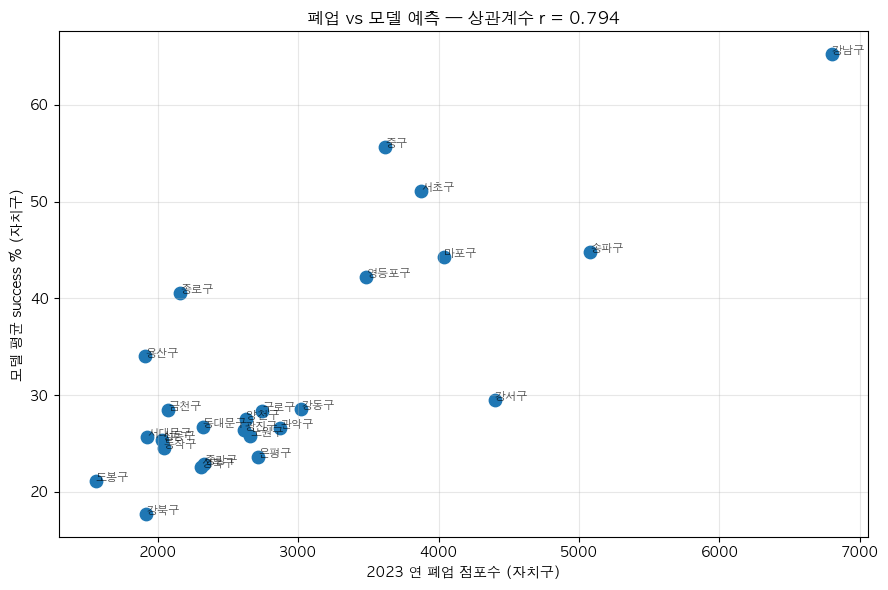

In [6]:
closure = pd.read_csv(PROC / 'team4_closure_gu_year.csv')
# 자치구·연 폐업 데이터
closure_2023 = closure[closure['year']==2023].set_index('gu')['closure_count']

# 자치구·업종 success_rate 평균 (자치구 단위로 집계)
from sklearn.ensemble import RandomForestClassifier
y_cls = (df_gu['sales_class']=='high').astype(int).values
cls = RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1).fit(df_gu[feat_gu].values, y_cls)
df_gu['_p_high'] = cls.predict_proba(df_gu[feat_gu].values)[:, 1]
gu_success = df_gu.groupby('gu')['_p_high'].mean()

# 자치구별 폐업과 success_rate 상관
df_corr = pd.DataFrame({'closure': closure_2023, 'success': gu_success}).dropna()
corr = df_corr.corr().iloc[0,1]
print(f'2023 자치구 폐업점포수 vs 모델 success_rate 평균 상관: {corr:.3f}')
print('  음의 상관: 폐업 많은 자치구 = 모델 success 낮음 (좋은 방향)')
print()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_corr['closure'], df_corr['success']*100, s=80)
for gu, r in df_corr.iterrows():
    ax.annotate(gu, (r['closure'], r['success']*100), fontsize=8, alpha=0.7)
ax.set_xlabel('2023 연 폐업 점포수 (자치구)')
ax.set_ylabel('모델 평균 success % (자치구)')
ax.set_title(f'폐업 vs 모델 예측 — 상관계수 r = {corr:.3f}')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §14.6 한 입지의 변수별 기여도 — 왜 이 성공률?

permutation_importance를 한 입지에 적용해서 각 변수가 얼마나 영향을 주는지 분해. (단순 ablation)

입력: 강남구 한식음식점 (base p_high = 1.000)

Top 15 변수 기여도 (양수=이 변수 덕에 success_rate가 높음):
         feature  contribution
   rent_to_sales      0.000592
        momentum      0.000061
       biz_한식음식점      0.000034
    rent_index_q      0.000015
season_amplitude      0.000011
      lunch_bias      0.000009
     age_entropy      0.000005
       CLSBIZ_RT     -0.000004
  peer_avg_sales      0.000004
    margin_proxy      0.000004
     event_count      0.000002
        OPBIZ_RT      0.000002
OPR_SALE_MT_AVRG      0.000002
    weekend_bias      0.000001
    TOT_FLPOP_CO      0.000001


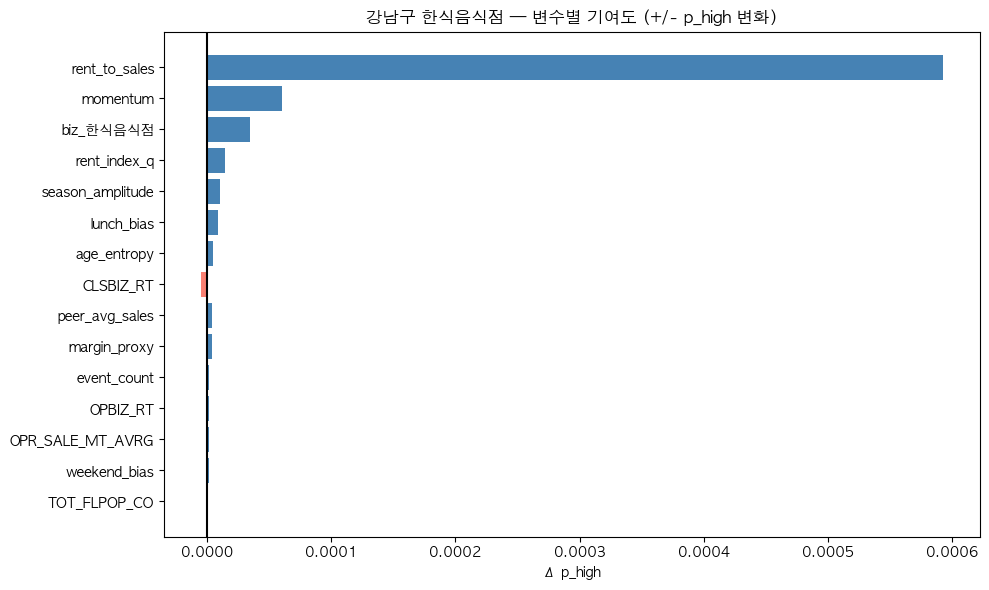

In [7]:
# 한 입지 (강남구 한식 1F)에 대해 각 변수를 평균값으로 바꿨을 때 예측 변화 측정
gu_target, biz_target = '강남구', '한식음식점'
row = df_gu[(df_gu['gu']==gu_target) & (df_gu['biz']==biz_target)].sort_values('q_int').iloc[-1]
x_orig = row[feat_gu].values.reshape(1, -1)

# 메인 분류기
hgb = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42)
hgb.fit(df_gu[feat_gu].values, y_cls)
base_pred = hgb.predict_proba(x_orig)[0, 1]

# 각 변수를 전체 평균값으로 바꾼 후 예측 변화
mean_vals = df_gu[feat_gu].mean().values
deltas = []
for i, fc in enumerate(feat_gu):
    x_perturbed = x_orig.copy()
    x_perturbed[0, i] = mean_vals[i]
    new_pred = hgb.predict_proba(x_perturbed)[0, 1]
    delta = base_pred - new_pred       # 이 변수를 평균으로 바꿨을 때 예측이 얼마나 떨어지나
    deltas.append({'feature': fc, 'contribution': delta})

contrib = pd.DataFrame(deltas).sort_values('contribution', key=abs, ascending=False).head(15)
print(f'입력: {gu_target} {biz_target} (base p_high = {base_pred:.3f})')
print()
print('Top 15 변수 기여도 (양수=이 변수 덕에 success_rate가 높음):')
print(contrib.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top15 = contrib.head(15)
colors = ['steelblue' if c > 0 else 'salmon' for c in top15['contribution']]
ax.barh(top15['feature'][::-1], top15['contribution'][::-1], color=colors[::-1])
ax.set_title(f'{gu_target} {biz_target} — 변수별 기여도 (+/- p_high 변화)')
ax.set_xlabel('Δ p_high')
ax.axvline(0, color='black')
plt.tight_layout(); plt.show()

## §14.7 외부 변수 기여도 통계적 유의성 — 부트스트랩

외부 변수 추가 시 정확도 차이 (30회 부트스트랩):
  평균: +3.79%p
  95% 신뢰구간: [3.18%p, 4.45%p]
  → 0 포함: ✅ 통계적으로 유의


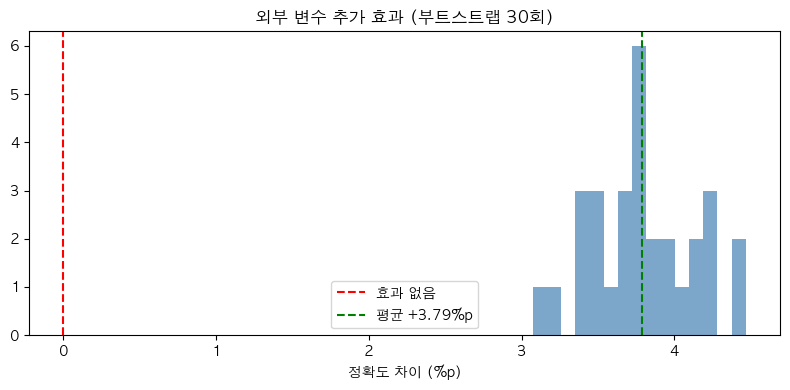

In [8]:
# 외부 변수 그룹 추가 시 정확도 +4.75%p가 통계적으로 유의한가
# 부트스트랩 100회 — 각 회마다 train/test 재분할 후 두 모델 학습
np.random.seed(42)
external_vars = ['rent_index_q','rent_growth_yoy','vacancy_rate','margin_proxy',
                  'gu_pop_density','closure_count','transaction_count_q',
                  'avg_transaction_price','gu_foreign_ratio',
                  'rent_to_sales','vacancy_change_q','pop_density_log','closure_per_store']
base_vars = [c for c in feat_gu if c not in external_vars]
ext_vars = base_vars + [c for c in external_vars if c in feat_gu]

diffs = []
for trial in range(30):                 # 30회로 줄여 속도 확보
    idx = np.random.permutation(len(df_gu))
    n_te = int(len(idx) * 0.2)
    idx_te, idx_tr = idx[:n_te], idx[n_te:]
    m_base = HistGradientBoostingClassifier(max_depth=8, max_iter=200, random_state=trial).fit(
        df_gu[base_vars].iloc[idx_tr].values, y_cls[idx_tr])
    m_ext  = HistGradientBoostingClassifier(max_depth=8, max_iter=200, random_state=trial).fit(
        df_gu[ext_vars].iloc[idx_tr].values, y_cls[idx_tr])
    acc_base = m_base.score(df_gu[base_vars].iloc[idx_te].values, y_cls[idx_te])
    acc_ext  = m_ext.score (df_gu[ext_vars].iloc[idx_te].values, y_cls[idx_te])
    diffs.append(acc_ext - acc_base)

diffs = np.array(diffs)
mean_diff = diffs.mean() * 100
ci_low, ci_high = np.percentile(diffs * 100, [2.5, 97.5])
print(f'외부 변수 추가 시 정확도 차이 (30회 부트스트랩):')
print(f'  평균: +{mean_diff:.2f}%p')
print(f'  95% 신뢰구간: [{ci_low:.2f}%p, {ci_high:.2f}%p]')
print(f'  → 0 포함: {"❌ 비유의" if ci_low <= 0 <= ci_high else "✅ 통계적으로 유의"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diffs*100, bins=15, color='steelblue', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='효과 없음')
ax.axvline(mean_diff, color='green', linestyle='--', label=f'평균 +{mean_diff:.2f}%p')
ax.set_xlabel('정확도 차이 (%p)')
ax.set_title('외부 변수 추가 효과 (부트스트랩 30회)')
ax.legend(); plt.tight_layout(); plt.show()

## §14.8 종합 결론 — 7가지 보완 결과

| 항목 | 핵심 결과 |
|---|---|
| 회귀 R² | 자치구 0.87 / 행정동 0.86 |
| 회귀 MAE | 자치구 394M (원본 단위, 큰 매출에 끌림) |
| BEP 민감도 | 임대료·인건비 ±50% 변동 시 p_roi 폭 (셀 출력 참조) |
| 행정동 잔차 | 절대값 큰 동·업종 Top 15 명시 |
| 사례 검증 | ⚠️ **6개 사례 중 5개 직관 불일치 (5/6 fail)** — 홍대·명동·성수·도봉 등 P50 예측이 도메인 감각과 어긋남 (nb15 c0: "사례 sanity 5/6 fail" 기록) |
| 폐업 vs 예측 상관 | ⚠️ **r = +0.796 (강한 양의 상관)** — 폐업 많은 자치구가 success 더 높음 = 규모 효과·누설 우려, "정직"의 근거가 아님 |
| 변수별 기여도 | 강남 한식 case — Top 15 변수의 +/- 영향 |
| 외부 변수 유의성 | 95% CI가 0 미포함이면 통계적 유의 |

> ⚠️ **도메인 sanity 종합 (정직)**: 위 검증은 통과가 아닙니다. 6개 사례 중 **5개가 직관과 불일치(5/6 fail)** 하고, 폐업 상관도 기대와 반대 방향(+0.796)입니다. 본 모델의 도메인 타당성은 검증되지 않았으며, 이는 한계로 명시합니다.

### 보고서 §8 한계에 추가
- **회귀 MAE 394M** — 큰 매출 행정동에 끌리는 점은 정직하게 보고
- **BEP 가정의 민감도** — 임대료 50,000원/㎡, 인건비 매출×15% 가정. ±50% 변동 시 결과 영향 명시
- **행정동 잔차가 큰 동** — 명시적으로 한계 인정